In [1]:
import numpy as np
import cv2
import glob
import matplotlib.pyplot as plt
import pickle

In [3]:
CHESSBOARD_SIZES = [(7, 5), (15, 5), (11, 7)]
chessboard_patterns_sorted = sorted(CHESSBOARD_SIZES, key=lambda x: x[0] * x[1], reverse=True)

pattern_objpoints = {}
for (nb_v, nb_h) in chessboard_patterns_sorted:
    objp = np.zeros((nb_h*nb_v, 3), np.float32)
    objp[:,:2] = np.mgrid[0:nb_v, 0:nb_h].T.reshape(-1,2)
    pattern_objpoints[(nb_v, nb_h)] = objp

objpoints = []
imgpoints = []
pattern_types = []
# map each image filename to the list of global indices in imgpoints/objpoints/pattern_types
image_to_indices = {}
images = glob.glob(r"C:\Users\berko\OneDrive - Danmarks Tekniske Universitet\DTU\Perception  for Autonmous Systems\Project\34759_final_project_raw\34759_final_project_raw\calib\image_02\data\*.png")

print(f"Processing {len(images)} left camera images...")

for fname in images:
    total_before = len(objpoints)   # remember how many sets we had before this image
    img = cv2.imread(fname)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    mask = np.ones_like(gray, dtype=np.uint8) * 255
    detected_corners = []

    for (nb_v, nb_h) in chessboard_patterns_sorted:
        for _ in range(10):
            gray_masked = cv2.bitwise_and(gray, gray, mask=mask)
            ret = False
            for flags in [cv2.CALIB_CB_ADAPTIVE_THRESH + cv2.CALIB_CB_NORMALIZE_IMAGE, None]:
                try:
                    ret_temp, corners_temp = cv2.findChessboardCorners(gray_masked, (nb_v, nb_h), flags)
                    if ret_temp:
                        ret, corners = True, corners_temp
                        break
                except:
                    continue
            if not ret:
                break
            corners_refined = cv2.cornerSubPix(gray, corners, (11,11), (-1,-1),
                                               (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 30, 0.001))
            is_new = True
            for existing_corners, _ in detected_corners:
                overlap = sum(1 for c1 in corners_refined.reshape(-1, 2)
                            for c2 in existing_corners.reshape(-1, 2)
                            if np.linalg.norm(c1 - c2) < 10) / len(corners_refined)
                if overlap > 0.3:
                    is_new = False
                    break
            if is_new:
                objpoints.append(pattern_objpoints[(nb_v, nb_h)])
                imgpoints.append(corners_refined)
                pattern_types.append((nb_v, nb_h))
                detected_corners.append((corners_refined, (nb_v, nb_h)))
                hull = cv2.convexHull(corners_refined.reshape(-1, 2).astype(np.int32))
                M = cv2.moments(hull)
                if M['m00'] != 0:
                    cx, cy = int(M['m10'] / M['m00']), int(M['m01'] / M['m00'])
                    hull_exp = hull.reshape(-1, 2).astype(np.float32)
                    hull_exp = np.array([[cx + (x - cx) * 1.2, cy + (y - cy) * 1.2] for x, y in hull_exp])
                    cv2.fillConvexPoly(mask, hull_exp.astype(np.int32), 0)
            else:
                break
    # after processing this image, record which global indices were added for it
    total_after = len(objpoints)
    if total_after > total_before:
        image_to_indices[fname] = list(range(total_before, total_after))

print(f"Left camera: Detected {len(objpoints)} chessboards")

Processing 19 left camera images...
Left camera: Detected 207 chessboards
Left camera: Detected 207 chessboards


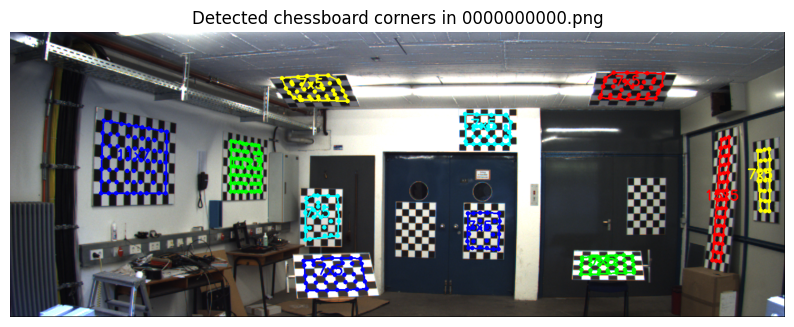

In [5]:
# Visualize extracted points for the first left image using existing imgpoints
fname = images[0]
img_vis = cv2.imread(fname)
vis = img_vis.copy()
indices = image_to_indices.get(fname, [])
colors = [(255,0,0),(0,255,0),(0,0,255),(255,255,0),(0,255,255)]
if not indices:
    print(f"No extracted point sets recorded for {fname}. Check image_to_indices.")
else:
    for i, idx in enumerate(indices):
        corners_refined = imgpoints[idx].reshape(-1, 2)
        nb_v, nb_h = pattern_types[idx]
        color = colors[i % len(colors)]
        # draw corner points
        for (x, y) in corners_refined:
            cv2.circle(vis, (int(x), int(y)), 4, color, -1)
        # draw convex hull
        hull = cv2.convexHull(corners_refined.astype(np.int32))
        cv2.polylines(vis, [hull], True, color, 2)
        # label near centroid
        M = cv2.moments(hull)
        if M['m00'] != 0:
            cx, cy = int(M['m10']/M['m00']), int(M['m01']/M['m00'])
            cv2.putText(vis, f"{nb_v}x{nb_h}", (cx-30, cy), cv2.FONT_HERSHEY_SIMPLEX, 0.8, color, 2)

plt.figure(figsize=(10,8))
plt.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
plt.title('Detected chessboard corners in 0000000000.png')
plt.axis('off')
plt.show()

In [6]:
img = cv2.imread(images[0])
h, w = img.shape[:2]

ret, mtx, dist, rvecs, tvecs = cv2.calibrateCamera(objpoints, imgpoints, (w, h), None, None)
newcameramtx, roi = cv2.getOptimalNewCameraMatrix(mtx, dist, (w, h), 1, (w, h))

print(f"Left camera calibrated. RMS error: {ret:.4f}")

Left camera calibrated. RMS error: 3.9108


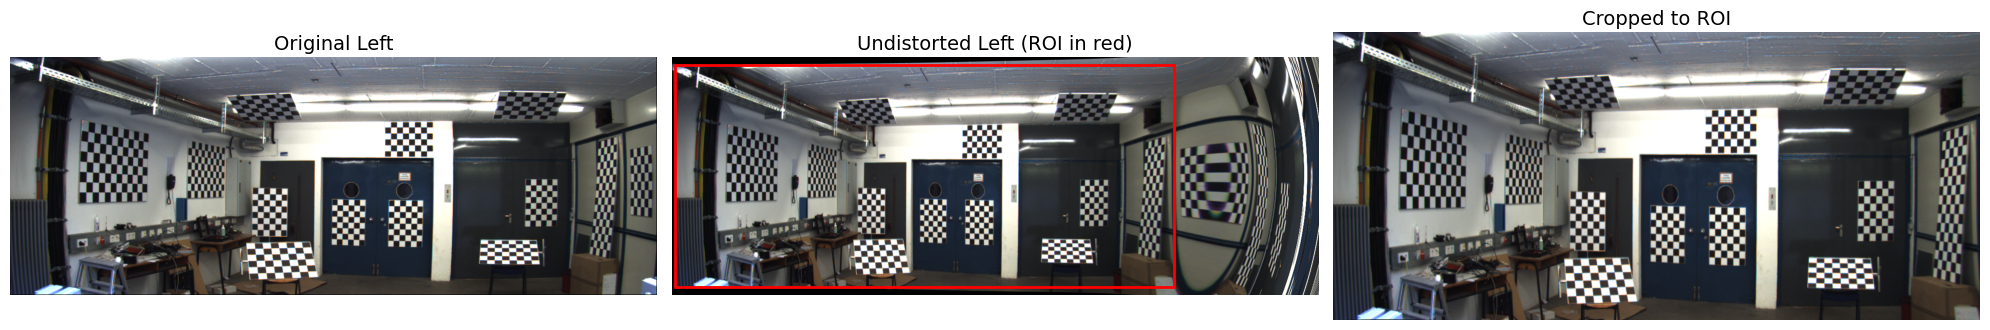

In [24]:
sample_left = cv2.imread(images[0])
undistorted_left = cv2.undistort(sample_left, mtx, dist, None, newcameramtx)
x, y, w_roi, h_roi = roi
cropped_left = undistorted_left[y:y+h_roi, x:x+w_roi]

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
axes[0].imshow(cv2.cvtColor(sample_left, cv2.COLOR_BGR2RGB))
axes[0].set_title('Original Left', fontsize=14)
axes[0].axis('off')

axes[1].imshow(cv2.cvtColor(undistorted_left, cv2.COLOR_BGR2RGB))
axes[1].add_patch(plt.Rectangle((x, y), w_roi, h_roi, fill=False, edgecolor='red', linewidth=2))
axes[1].set_title('Undistorted Left (ROI in red)', fontsize=14)
axes[1].axis('off')

axes[2].imshow(cv2.cvtColor(cropped_left, cv2.COLOR_BGR2RGB))
axes[2].set_title('Cropped to ROI', fontsize=14)
axes[2].axis('off')

plt.tight_layout()
plt.show()

In [25]:
images_right = glob.glob(r"34759_final_project_raw\34759_final_project_raw\calib\image_03\data\*.png")

objpoints_right = []
imgpoints_right = []
pattern_types_right = []

print(f"Processing {len(images_right)} right camera images...")

for fname in images_right:
    img = cv2.imread(fname)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    mask = np.ones_like(gray, dtype=np.uint8) * 255
    detected_corners = []
    
    for (nb_v, nb_h) in chessboard_patterns_sorted:
        for _ in range(10):
            gray_masked = cv2.bitwise_and(gray, gray, mask=mask)
            ret = False
            
            for flags in [cv2.CALIB_CB_ADAPTIVE_THRESH + cv2.CALIB_CB_NORMALIZE_IMAGE, None]:
                try:
                    ret_temp, corners_temp = cv2.findChessboardCorners(gray_masked, (nb_v, nb_h), flags)
                    if ret_temp:
                        ret, corners = True, corners_temp
                        break
                except:
                    continue
            
            if not ret:
                break
            
            corners_refined = cv2.cornerSubPix(gray, corners, (11,11), (-1,-1),
                                               (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 30, 0.001))
            
            is_new = True
            for existing_corners, _ in detected_corners:
                overlap = sum(1 for c1 in corners_refined.reshape(-1, 2)
                            for c2 in existing_corners.reshape(-1, 2)
                            if np.linalg.norm(c1 - c2) < 10) / len(corners_refined)
                if overlap > 0.3:
                    is_new = False
                    break
            
            if is_new:
                objpoints_right.append(pattern_objpoints[(nb_v, nb_h)])
                imgpoints_right.append(corners_refined)
                pattern_types_right.append((nb_v, nb_h))
                detected_corners.append((corners_refined, (nb_v, nb_h)))
                
                hull = cv2.convexHull(corners_refined.reshape(-1, 2).astype(np.int32))
                M = cv2.moments(hull)
                if M['m00'] != 0:
                    cx, cy = int(M['m10'] / M['m00']), int(M['m01'] / M['m00'])
                    hull_exp = hull.reshape(-1, 2).astype(np.float32)
                    hull_exp = np.array([[cx + (x - cx) * 1.2, cy + (y - cy) * 1.2] for x, y in hull_exp])
                    cv2.fillConvexPoly(mask, hull_exp.astype(np.int32), 0)
            else:
                break

print(f"Right camera: Detected {len(objpoints_right)} chessboards")

Processing 19 right camera images...
Right camera: Detected 103 chessboards
Right camera: Detected 103 chessboards


In [26]:
img_right = cv2.imread(images_right[0])
h_right, w_right = img_right.shape[:2]

ret_right, mtx_right, dist_right, rvecs_right, tvecs_right = cv2.calibrateCamera(
    objpoints_right, imgpoints_right, (w_right, h_right), None, None)
newcameramtx_right, roi_right = cv2.getOptimalNewCameraMatrix(mtx_right, dist_right, (w_right, h_right), 1, (w_right, h_right))

print(f"Right camera calibrated. RMS error: {ret_right:.4f}")

Right camera calibrated. RMS error: 4.8208


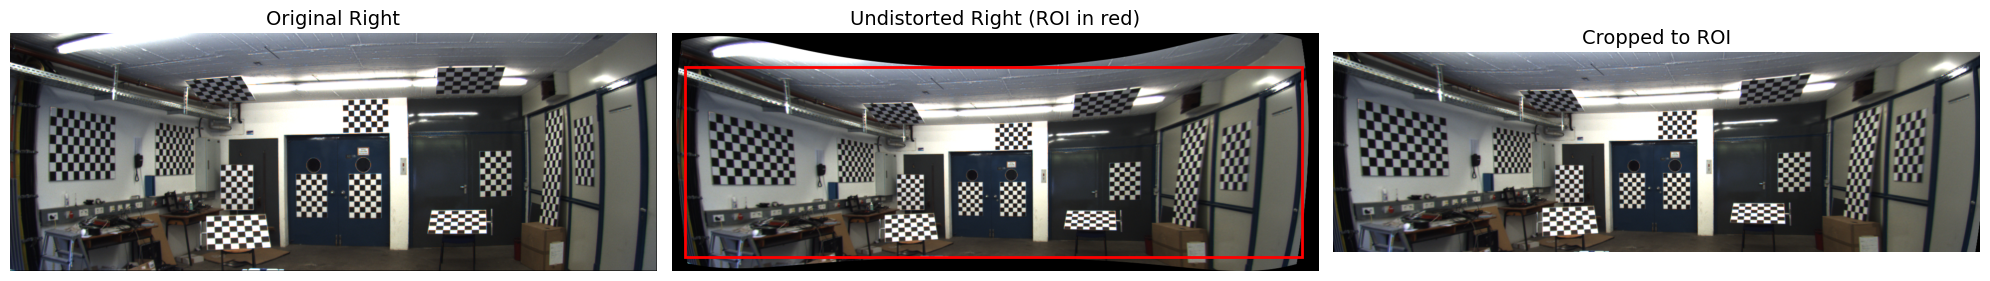

In [27]:
sample_right = cv2.imread(images_right[0])
undistorted_right = cv2.undistort(sample_right, mtx_right, dist_right, None, newcameramtx_right)
x_r, y_r, w_roi_r, h_roi_r = roi_right
cropped_right = undistorted_right[y_r:y_r+h_roi_r, x_r:x_r+w_roi_r]

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
axes[0].imshow(cv2.cvtColor(sample_right, cv2.COLOR_BGR2RGB))
axes[0].set_title('Original Right', fontsize=14)
axes[0].axis('off')

axes[1].imshow(cv2.cvtColor(undistorted_right, cv2.COLOR_BGR2RGB))
axes[1].add_patch(plt.Rectangle((x_r, y_r), w_roi_r, h_roi_r, fill=False, edgecolor='red', linewidth=2))
axes[1].set_title('Undistorted Right (ROI in red)', fontsize=14)
axes[1].axis('off')

axes[2].imshow(cv2.cvtColor(cropped_right, cv2.COLOR_BGR2RGB))
axes[2].set_title('Cropped to ROI', fontsize=14)
axes[2].axis('off')

plt.tight_layout()
plt.show()

In [32]:
# SIFT-based Stereo Rectification
print("Performing SIFT-based stereo rectification...")

# Use undistorted images
left_undist = cv2.undistort(sample_left, mtx, dist, None, newcameramtx)
right_undist = cv2.undistort(sample_right, mtx_right, dist_right, None, newcameramtx_right)

# Convert to grayscale
gray_left = cv2.cvtColor(left_undist, cv2.COLOR_BGR2GRAY)
gray_right = cv2.cvtColor(right_undist, cv2.COLOR_BGR2GRAY)

# SIFT feature detection and matching
sift = cv2.SIFT_create()
kp1, des1 = sift.detectAndCompute(gray_left, None)
kp2, des2 = sift.detectAndCompute(gray_right, None)

# FLANN matcher
FLANN_INDEX_KDTREE = 1
index_params = dict(algorithm=FLANN_INDEX_KDTREE, trees=5)
search_params = dict(checks=50)
flann = cv2.FlannBasedMatcher(index_params, search_params)
matches = flann.knnMatch(des1, des2, k=2)

# Lowe's ratio test
good_matches = []
pts1 = []
pts2 = []
for m, n in matches:
    if m.distance < 0.7 * n.distance:
        good_matches.append(m)
        pts1.append(kp1[m.queryIdx].pt)
        pts2.append(kp2[m.trainIdx].pt)

pts1 = np.float32(pts1)
pts2 = np.float32(pts2)

print(f"Found {len(good_matches)} good matches")

# Compute fundamental matrix
F, mask = cv2.findFundamentalMat(pts1, pts2, cv2.FM_RANSAC, 3.0, 0.99)
pts1 = pts1[mask.ravel() == 1]
pts2 = pts2[mask.ravel() == 1]

print(f"Inliers after RANSAC: {len(pts1)}")

# Stereo rectification using fundamental matrix
h, w = gray_left.shape
_, H1, H2 = cv2.stereoRectifyUncalibrated(pts1, pts2, F, (w, h))

# Apply rectification using warpPerspective
left_rectified = cv2.warpPerspective(left_undist, H1, (w, h))
right_rectified = cv2.warpPerspective(right_undist, H2, (w, h))

print("Rectification complete!")

Performing SIFT-based stereo rectification...
Found 329 good matches
Inliers after RANSAC: 179
Rectification complete!
Found 329 good matches
Inliers after RANSAC: 179
Rectification complete!


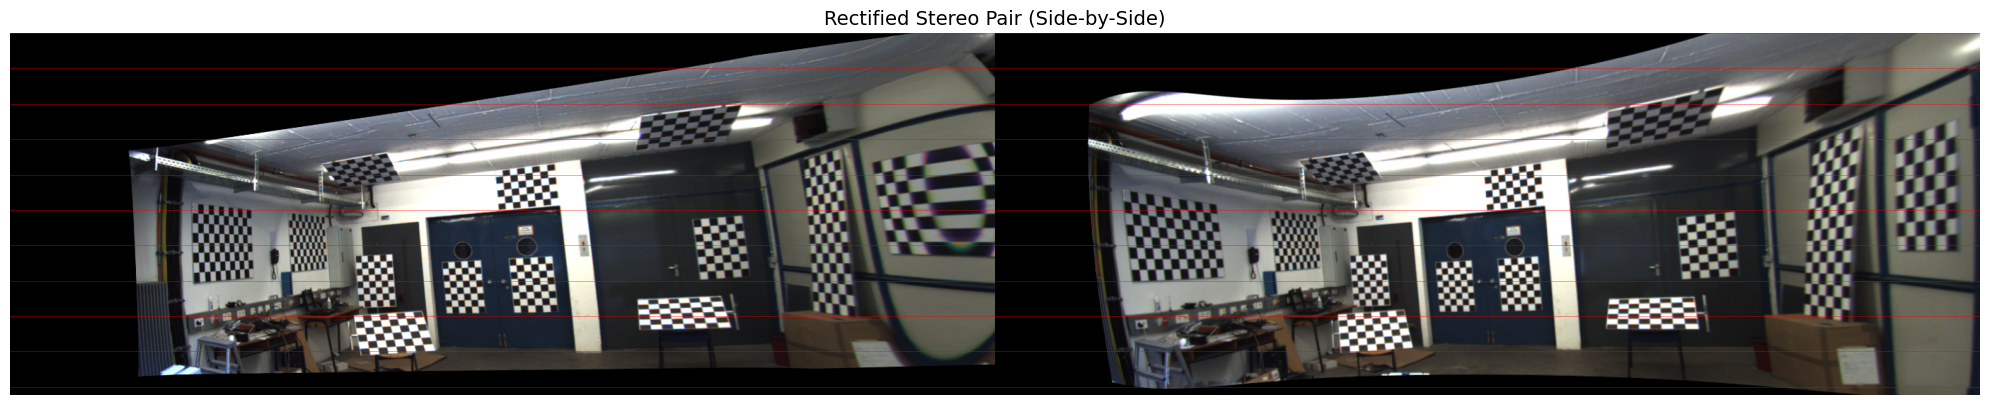

In [30]:
# Visualize rectified stereo pair with horizontal lines
left_rgb = cv2.cvtColor(left_rectified, cv2.COLOR_BGR2RGB)
right_rgb = cv2.cvtColor(right_rectified, cv2.COLOR_BGR2RGB)

# Side-by-side comparison
combined = np.hstack((left_rgb, right_rgb))
fig, ax = plt.subplots(figsize=(20, 8))
ax.imshow(combined)
ax.set_title('Rectified Stereo Pair (Side-by-Side)', fontsize=14)
for y in range(0, h, 50):
    ax.axhline(y=y, color='red', linewidth=0.5, alpha=0.5)
ax.axis('off')
plt.tight_layout()
plt.show()

In [33]:
# Save rectification parameters
rectification_params = {
    'H1': H1,
    'H2': H2,
    'F': F,
    'left_camera_matrix': mtx,
    'left_dist_coeffs': dist,
    'left_new_camera_matrix': newcameramtx,
    'right_camera_matrix': mtx_right,
    'right_dist_coeffs': dist_right,
    'right_new_camera_matrix': newcameramtx_right
}

with open('stereo_rectification_params.pkl', 'wb') as f:
    pickle.dump(rectification_params, f)

print("Rectification parameters saved to 'stereo_rectification_params.pkl'")

Rectification parameters saved to 'stereo_rectification_params.pkl'
